Sobel Edge Detection

Text(0.5, 1.0, 'Sobel-y edge detection')

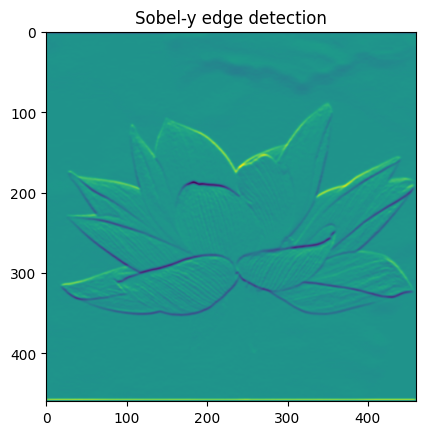

In [1]:
import cv2
import matplotlib.pyplot as plt
img = cv2.imread('lotus.jpg') 
if img is None:
    print("Could not read the image.")
    exit()
RGB_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(RGB_img, cv2.COLOR_BGR2GRAY)
img = cv2.GaussianBlur(gray,(3,3),0)
sobelx = cv2.Sobel(img,cv2.CV_64F,1,0,ksize=5) # x
sobely = cv2.Sobel(img,cv2.CV_64F,0,1,ksize=5) # y
plt.imshow(sobelx)
plt.title("Sobel-x edge detection")
plt.imshow(sobely)
plt.title("Sobel-y edge detection")

Sobel Edge Detection

In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Read image in grayscale
img = cv2.imread('lotus.jpg', 0)
if img is None:
    print("Could not read the image.")
    exit()

# Apply Gaussian Blur to reduce noise
img = cv2.GaussianBlur(img, (3,3), 0)

# Sobel Kernels
kx = np.array([[-1,0,1],[-2,0,2],[-1,0,1]], np.float32)
ky = np.array([[1,2,1],[0,0,0],[-1,-2,-1]], np.float32)

# Initialize output arrays
m, n = img.shape
img_new = np.zeros([m, n])
img_new1 = np.zeros([m, n])

# Convolution with Sobel X
for i in range(1, m-1):
    for j in range(1, n-1):
        temp1 = (img[i-1, j-1]*kx[0,0] + img[i-1, j]*kx[0,1] + img[i-1, j+1]*kx[0,2] +
                 img[i, j-1]*kx[1,0]   + img[i, j]*kx[1,1]   + img[i, j+1]*kx[1,2] +
                 img[i+1, j-1]*kx[2,0] + img[i+1, j]*kx[2,1] + img[i+1, j+1]*kx[2,2])
        img_new[i, j] = temp1

# Convolution with Sobel Y
for i in range(1, m-1):
    for j in range(1, n-1):
        temp2 = (img[i-1, j-1]*ky[0,0] + img[i-1, j]*ky[0,1] + img[i-1, j+1]*ky[0,2] +
                 img[i, j-1]*ky[1,0]   + img[i, j]*ky[1,1]   + img[i, j+1]*ky[1,2] +
                 img[i+1, j-1]*ky[2,0] + img[i+1, j]*ky[2,1] + img[i+1, j+1]*ky[2,2])
        img_new1[i, j] = temp2

# Convert to uint8
img_new = img_new.astype(np.uint8)
img_new1 = img_new1.astype(np.uint8)

# Gradient Magnitude
G = np.sqrt(np.square(img_new) + np.square(img_new1))
if G.max() != 0:
    G = (G / G.max()) * 255
G = G.astype(np.uint8)

# Show results
cv2.imshow('Sobel X', img_new)
cv2.imshow('Sobel Y', img_new1)
cv2.imshow('Gradient Magnitude', G)
cv2.waitKey(0)
cv2.destroyAllWindows()
